# Gaza War-Damage Prototype Pipeline — Sentinel-1 SAR + PWTT Labels + CNN

**Part 2 prototype for the "Quantifying War Damage from Satellite Imagery" project.**

This notebook is a *minimal end-to-end pipeline*, not a final model:

1. **Labels/footprints** — PWTT `one_month` benchmark for **Gaza (2024-05-03)**:
   Microsoft building footprints labeled damaged/undamaged via UNOSAT points
   (`one_month/Gaza_20240503_1_footprints.csv`, from
   [oballinger/PWTT](https://github.com/oballinger/PWTT)).
2. **Imagery** — Sentinel-1 SAR (VV+VH) from **Google Earth Engine**: a *pre-war*
   median composite and a *post* composite covering the month before the UNOSAT
   assessment date, exported as one 4-band GeoTIFF.
3. **Patches** — 32×32 px (~320 m) chips around each building centroid, channels
   `[pre_VV, pre_VH, post_VV, post_VH]` (channel-stacking; a siamese design is the
   obvious next variant).
4. **Model** — a compact from-scratch CNN with class-weighted loss.
5. **Evaluation** — *spatial* hold-out (southern third of the sampled buildings),
   precision / recall / F1 / PR-AUC, compared against the PWTT `max_change`
   statistic as a non-deep-learning baseline.

**Why SAR:** Sentinel-1 is unaffected by clouds/smoke, freely available, and revisits
every ~6–12 days — this is the same signal PWTT itself is computed from, so the CNN is
essentially trying to beat a hand-crafted statistic on the same raw data.

**Prerequisites**
- The PWTT benchmark zip extracted so `one_month/Gaza_20240503_1_footprints.csv`
  sits next to this notebook (same layout as the preliminary EDA notebook).
- A Google Earth Engine account for the export step (Section 2). Everything after
  Section 2 only needs the exported GeoTIFF — so you run the GEE cell **once**.
- `pip install earthengine-api geemap geopandas rasterio torch scikit-learn`


In [ ]:
import os, json, glob
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)
!pip install earthengine-api geemap geopandas rasterio torch scikit-learn geedim

# ---------------- Configuration ----------------
DATA_DIR      = "/content/drive/MyDrive/War-Damage-Detection/one_month"
CITY, DATE    = "Gaza", "20240503"          # UNOSAT assessment date used for labels
WAR_START     = "2023-10-07"                # conflict start
LABEL_DATE    = "2024-05-03"
PRE_MONTHS    = 12                          # pre-war window: 12 months before WAR_START
                                            #   (PWTT default pre_interval)
POST_MONTHS   = 1                           # post window length ('one_month' benchmark)
POST_DIRECTION = "forward"                  # "forward":  [LABEL_DATE, +POST_MONTHS]
                                            #    -> PWTT convention; matches how the
                                            #       k50/max_change columns were computed.
                                            # "backward": [LABEL_DATE -POST_MONTHS, LABEL_DATE]
                                            #    -> no imagery after the assessment date.
                                            # See Section 2 for the tradeoff.
GEE_PROJECT   = "test-cnn-war-damage"       # your Earth Engine cloud project
RASTER_PATH   = f"gaza_s1_stack_{POST_DIRECTION}.tif"   # produced in Section 2
N_SAMPLE      = 4000                        # buildings to sample for the prototype
PATCH         = 32                          # patch size in pixels (10 m px -> ~320 m)
SEED          = 0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Gaza footprints + labels (PWTT `one_month`)

Same parsing as the preliminary EDA notebook: the `.geo` column holds GeoJSON polygon
geometry (WGS84). Gaza has ~200k+ footprints and a ~57% damage rate at this date, so
for a **prototype** we take a random sample — the class balance here is unusually
favorable; when you scale to other cities the sparsity problem returns in full force.

In [ ]:
def load_footprints(path):
    df = pd.read_csv(path, low_memory=False)
    geoms = [shape(json.loads(g)) for g in df[".geo"]]
    return gpd.GeoDataFrame(df.drop(columns=[".geo"]), geometry=geoms, crs="EPSG:4326")

fp_path = os.path.join(DATA_DIR, f"{CITY}_{DATE}_1_footprints.csv")
gdf_full = load_footprints(fp_path)
print(f"{len(gdf_full):,} footprints, {gdf_full['class'].mean()*100:.1f}% labeled damaged")

# Random prototype sample (reproducible)
gdf = gdf_full.sample(n=min(N_SAMPLE, len(gdf_full)), random_state=SEED).copy()
# Compute centroids in a projected CRS (correct geometry math), then back to lon/lat
gdf["centroid"] = gdf.geometry.to_crs(3857).centroid.to_crs(4326)
print(f"sampled {len(gdf):,} buildings, {gdf['class'].mean()*100:.1f}% damaged")

# Bounding box (small buffer) that the SAR export must cover
minx, miny, maxx, maxy = gdf.total_bounds
BUF = 0.005  # ~500 m
BBOX = [minx - BUF, miny - BUF, maxx + BUF, maxy + BUF]
print("export bbox:", [round(v, 4) for v in BBOX])

228,730 footprints, 57.5% labeled damaged
sampled 4,000 buildings, 57.3% damaged
export bbox: [np.float64(34.2157), np.float64(31.2364), np.float64(34.5562), np.float64(31.5771)]


## 2. Google Earth Engine: build + export the Sentinel-1 stack  *(run once)*

Builds two median composites from `COPERNICUS/S1_GRD` (dB-scaled GRD) and exports
`[pre_VV, pre_VH, post_VV, post_VH]` at 10 m as a single GeoTIFF.

**Pre-window:** `WAR_START − 12 months → WAR_START`. A full year avoids biasing the
baseline toward whatever the seasonal vegetation/moisture state happened to be.

**Post-window — set by `POST_DIRECTION`.** Damage is cumulative (once a building is
rubble it stays rubble), so the composite encodes damage accrued up to the window's
*end*; the window's start only controls how much pre-destruction imagery is averaged in.
That gives a clean tradeoff:

| | window | risk |
|---|---|---|
| `"forward"` | `LABEL_DATE → +1 month` | buildings destroyed *during* the window are labeled undamaged → noise in the negatives |
| `"backward"` | `LABEL_DATE − 1 month → LABEL_DATE` | buildings destroyed *during* the window are half pre- / half post-destruction in the median → diluted positives |

`"forward"` is the default here because (a) it's PWTT's convention — `post` runs from
`inference_start` forward by `post_interval` — so the CNN and the `max_change` baseline
in Section 6 see comparable imagery, and (b) dilution hurts the class you have fewest
examples of. The cost is ~1 month of lookahead past the assessment date, which belongs
in the limitations section of your report. Running both and comparing is a cheap
experiment.

**Orbit selection.** Pre and post must come from the same relative orbit — mixing
orbits injects incidence-angle differences that look like change but aren't damage. We
count images per orbit in *both* windows and pick one that's well sampled in each;
picking on post-window counts alone can select an orbit with almost no pre-war coverage,
which makes `pre.median()` silently unreliable or masked.

Two further prototype simplifications, each an upgrade path: median compositing is a
cheap speckle suppressor (PWTT uses `S1_GRD_FLOAT` + Lee filtering + per-orbit t-tests),
and ~50 km² at 10 m × 4 float bands is only tens of MB, so `geemap.download_ee_image`
pulls it straight to disk with no Drive export.

In [ ]:
def build_s1_composites(verbose=True):
    """Build same-orbit pre/post Sentinel-1 median composites over BBOX.

    Requires ee.Initialize() to have been called. Returns (pre, post, aoi, best_orbit).
    Used by both the export cell below and the interactive map in Section 6b.
    """
    import ee
    aoi = ee.Geometry.Rectangle(BBOX)
    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD")
          .filterBounds(aoi)
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
          .select(["VV", "VH"]))

    war, label = ee.Date(WAR_START), ee.Date(LABEL_DATE)
    pre_start, pre_end = war.advance(-PRE_MONTHS, "month"), war
    if POST_DIRECTION == "forward":       # PWTT convention
        post_start, post_end = label, label.advance(POST_MONTHS, "month")
    elif POST_DIRECTION == "backward":    # no imagery after the assessment date
        post_start, post_end = label.advance(-POST_MONTHS, "month"), label
    else:
        raise ValueError("POST_DIRECTION must be 'forward' or 'backward'")

    # aggregate_histogram returns STRING keys, and relativeOrbitNumber_start is
    # stored as a double -> keys look like '160.0'. int('160.0') raises; go via float.
    def orbit_counts(start, end):
        h = (s1.filterDate(start, end)
               .aggregate_histogram("relativeOrbitNumber_start").getInfo())
        return {int(float(k)): int(v) for k, v in h.items()}

    pre_counts  = orbit_counts(pre_start, pre_end)
    post_counts = orbit_counts(post_start, post_end)
    shared = set(pre_counts) & set(post_counts)
    if not shared:
        raise RuntimeError(f"No orbit covers both windows.\npre={pre_counts}\npost={post_counts}")

    # Prefer the orbit whose *weaker* window is best sampled; break ties on post count.
    best_orbit = max(shared, key=lambda o: (min(pre_counts[o], post_counts[o]), post_counts[o]))
    if verbose:
        print("pre  images per orbit:", pre_counts)
        print("post images per orbit:", post_counts)
        print(f"-> orbit {best_orbit}  "
              f"({pre_counts[best_orbit]} pre / {post_counts[best_orbit]} post images)")
        if post_counts[best_orbit] < 3:
            print("WARNING: thin post stack — a 1-month single-orbit window is only ~2-3 "
                  "acquisitions. Consider POST_MONTHS=2 (PWTT's default) and note the "
                  "deviation from the 'one_month' benchmark.")

    # ee.Filter.eq compares numerically, so a Python int matches the stored double.
    s1 = s1.filter(ee.Filter.eq("relativeOrbitNumber_start", best_orbit))
    pre  = s1.filterDate(pre_start,  pre_end).median()
    post = s1.filterDate(post_start, post_end).median()
    return pre, post, aoi, best_orbit

In [ ]:
if not os.path.exists(RASTER_PATH):
    import ee, geemap

    # First run: ee.Authenticate() opens a browser flow, then initialize with
    # your cloud project id.
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)

    pre, post, aoi, best_orbit = build_s1_composites()

    stack = (pre.rename(["pre_VV", "pre_VH"])
                .addBands(post.rename(["post_VV", "post_VH"]))
                .clip(aoi).toFloat())

    geemap.download_ee_image(stack, RASTER_PATH, region=aoi, scale=10,
                             crs="EPSG:4326")
    print("exported", RASTER_PATH)
else:
    print(f"{RASTER_PATH} already exists — skipping GEE export")

pre  images per orbit: {160: 31, 87: 30, 94: 30}
post images per orbit: {160: 3, 87: 3, 94: 3}
-> orbit 160  (31 pre / 3 post images)


/usr/local/lib/python3.12/dist-packages/geemap/common.py:12333: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/96 tiles [00:00<?]

exported gaza_s1_stack_forward.tif


/usr/local/lib/python3.12/dist-packages/geedim/image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


## 3. Extract pre/post patches around building centroids

One windowed read per building; skips buildings whose window would fall off the raster
edge or contains NaNs. Output: `X` of shape `(N, 4, 32, 32)` and labels `y`.

In [ ]:
import rasterio
from rasterio.windows import Window

def extract_patches(raster_path, gdf, patch=PATCH):
    X, y, keep = [], [], []
    with rasterio.open(raster_path) as src:
        assert src.count == 4, "expected 4 bands: pre_VV, pre_VH, post_VV, post_VH"
        for i, row in gdf.iterrows():
            c = row["centroid"]
            r, col = src.index(c.x, c.y)
            r0, c0 = r - patch // 2, col - patch // 2
            if r0 < 0 or c0 < 0 or r0 + patch > src.height or c0 + patch > src.width:
                continue
            arr = src.read(window=Window(c0, r0, patch, patch)).astype(np.float32)
            if np.isnan(arr).any():
                continue
            X.append(arr); y.append(int(row["class"])); keep.append(i)
    return np.stack(X), np.array(y), np.array(keep)

X, y, keep_idx = extract_patches(RASTER_PATH, gdf)
print(f"patches: {X.shape}   positives: {y.mean()*100:.1f}%")

patches: (4000, 4, 32, 32)   positives: 57.3%


### 3b. What the SAR actually sees — pre / post / change per building

Intact buildings act as **corner reflectors**: the wall-ground right angle bounces the
radar pulse straight back, so urban structure is bright (high dB). Rubble scatters the
pulse in random directions, so a destroyed building typically goes **darker** — that
drop is the signal the CNN is looking for. Below: pre-war VV, post VV, and their
difference for high-confidence examples of each class (buildings with the strongest /
weakest PWTT `max_change`, so the visual signal is clear).

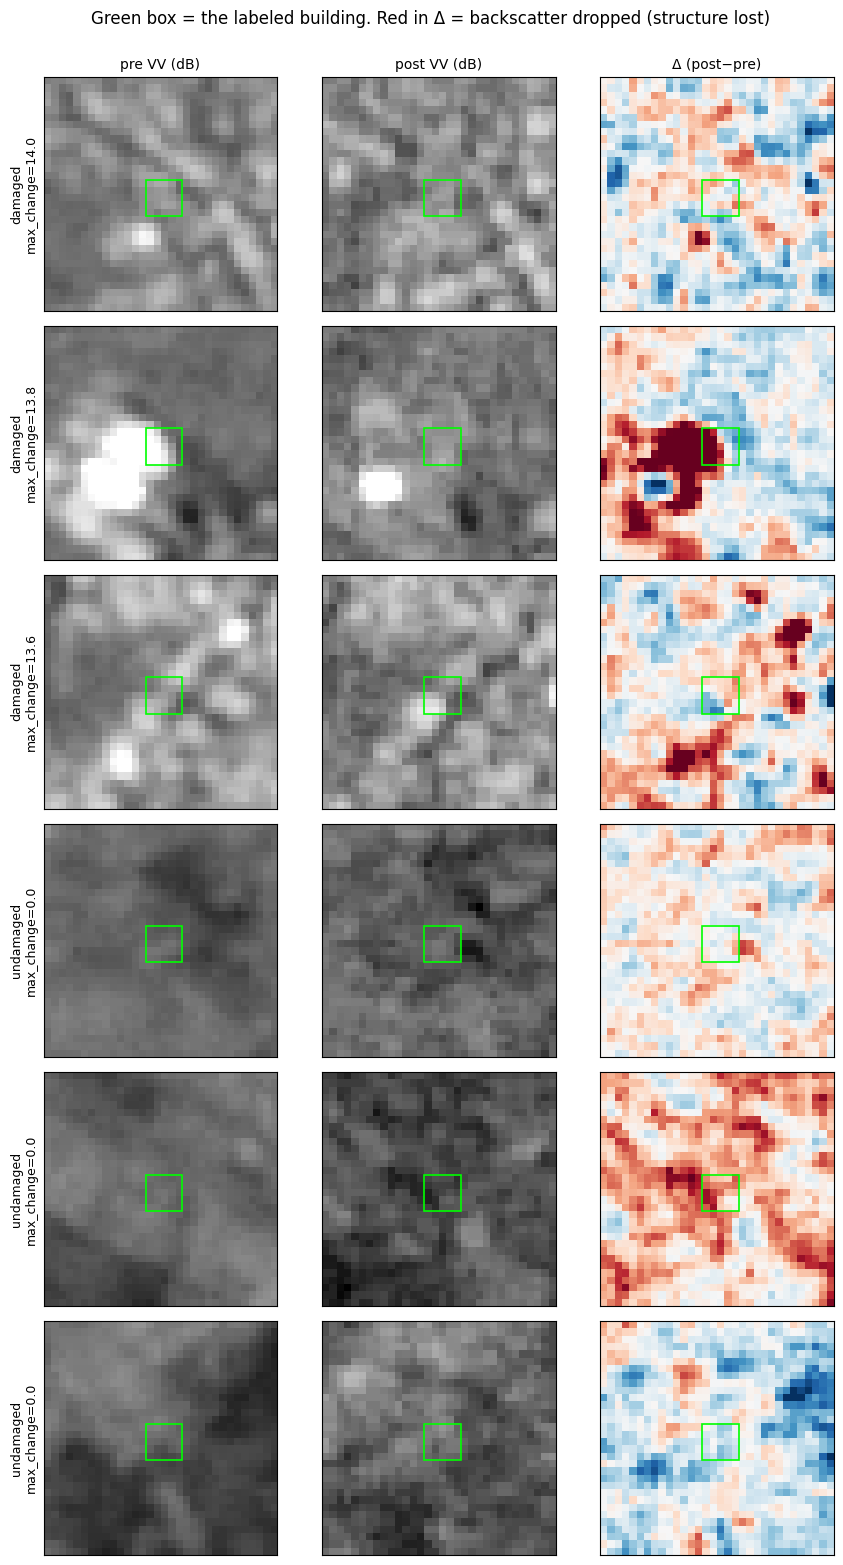

In [ ]:
def show_triptychs(X, y, gdf, keep_idx, n_each=3):
    mc_all = gdf.loc[keep_idx, "max_change"].values
    dmg  = np.where(y == 1)[0];  dmg  = dmg[np.argsort(-mc_all[dmg])][:n_each]
    ok   = np.where(y == 0)[0];  ok   = ok[np.argsort(mc_all[ok])][:n_each]
    rows = [(j, "damaged") for j in dmg] + [(j, "undamaged") for j in ok]

    fig, axes = plt.subplots(len(rows), 3, figsize=(9, 2.6 * len(rows)))
    for ax_row, (j, name) in zip(axes, rows):
        pre_vv, post_vv = X[j, 0], X[j, 2]
        for ax, img, title, kw in [
            (ax_row[0], pre_vv,  "pre VV (dB)",  dict(cmap="gray", vmin=-22, vmax=2)),
            (ax_row[1], post_vv, "post VV (dB)", dict(cmap="gray", vmin=-22, vmax=2)),
            (ax_row[2], post_vv - pre_vv, "Δ (post−pre)", dict(cmap="RdBu", vmin=-8, vmax=8)),
        ]:
            ax.imshow(img, **kw)
            ax.set_xticks([]); ax.set_yticks([])
            if ax is ax_row[0]:
                ax.set_ylabel(f"{name}\nmax_change={mc_all[j]:.1f}", fontsize=9)
            if j == rows[0][0]:
                ax.set_title(title, fontsize=10)
            # mark the labeled building at patch center (~2x2 px building on 32px patch)
            ax.add_patch(plt.Rectangle((PATCH//2 - 2.5, PATCH//2 - 2.5), 5, 5,
                                       fill=False, edgecolor="lime", linewidth=1.2))
    fig.suptitle("Green box = the labeled building. Red in Δ = backscatter dropped "
                 "(structure lost)", y=1.0)
    plt.tight_layout(); plt.show()

show_triptychs(X, y, gdf, keep_idx)

### 3b-ii. Report-ready static example — one building, footprint outlined

Same triptych for a single high-confidence damaged building, but larger, with the
actual **footprint polygon** projected into patch pixel coordinates (instead of a
generic center box), coordinates in the title, and saved to PNG for the report.

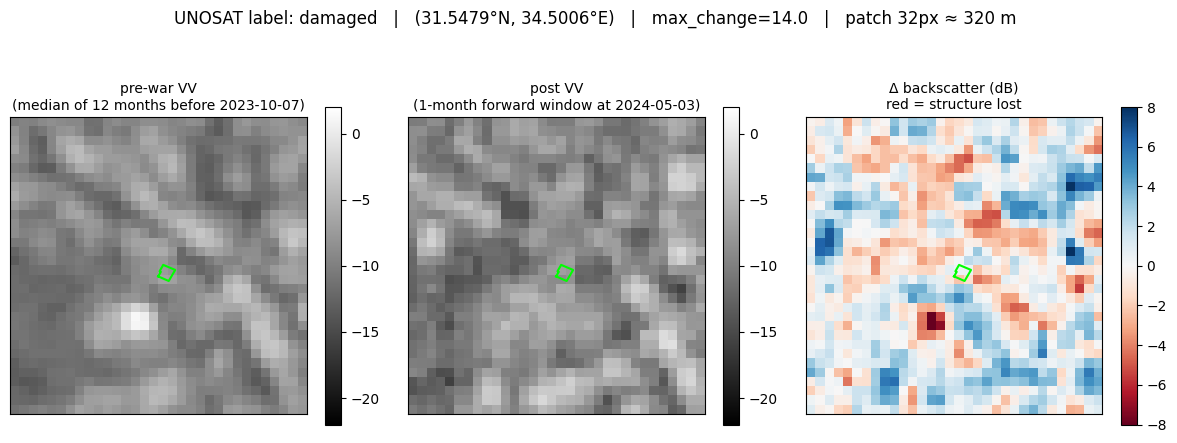

saved example_patch.png


In [ ]:
def static_patch_figure(building_pos, save_path="example_patch.png"):
    """building_pos: positional index into X/y/keep_idx."""
    row = gdf.loc[keep_idx[building_pos]]
    c = row["centroid"]
    with rasterio.open(RASTER_PATH) as src:
        r, col = src.index(c.x, c.y)
        r0, c0 = r - PATCH // 2, col - PATCH // 2
        inv = ~src.transform
        # footprint exterior -> patch pixel coords (x=col-c0, y=row-r0)
        px = [(inv * (x, yy))[0] - c0 for x, yy in row.geometry.exterior.coords]
        py = [(inv * (x, yy))[1] - r0 for x, yy in row.geometry.exterior.coords]

    pre_vv, post_vv = X[building_pos, 0], X[building_pos, 2]
    panels = [(pre_vv, f"pre-war VV\n(median of {PRE_MONTHS} months before "
                       f"{WAR_START})", dict(cmap="gray", vmin=-22, vmax=2)),
              (post_vv, f"post VV\n({POST_MONTHS}-month {POST_DIRECTION} window "
                        f"at {LABEL_DATE})", dict(cmap="gray", vmin=-22, vmax=2)),
              (post_vv - pre_vv, "Δ backscatter (dB)\nred = structure lost",
               dict(cmap="RdBu", vmin=-8, vmax=8))]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))
    for ax, (img, title, kw) in zip(axes, panels):
        im = ax.imshow(img, **kw)
        ax.plot(px, py, color="lime", linewidth=1.5)
        ax.set_xlim(-0.5, PATCH - 0.5); ax.set_ylim(PATCH - 0.5, -0.5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.8)
    lab = "damaged" if y[building_pos] == 1 else "undamaged"
    fig.suptitle(f"UNOSAT label: {lab}   |   ({c.y:.4f}°N, {c.x:.4f}°E)   |   "
                 f"max_change={row['max_change']:.1f}   |   "
                 f"patch {PATCH}px ≈ {PATCH*10} m", y=1.02)
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved", save_path)

# strongest-signal damaged example; pass any other index to inspect a different building
mc_all = gdf.loc[keep_idx, "max_change"].values
dmg_pos = np.where(y == 1)[0]
best_dmg = dmg_pos[np.argmax(mc_all[dmg_pos])]
static_patch_figure(best_dmg)

### 3c. City-wide change map from the exported raster

The same ΔVV signal over the whole strip, with the sampled damage labels overlaid —
the SAR analogue of the damage maps from the EDA notebook. Expect the red (backscatter
loss) to co-locate with the labeled damage clusters; where it doesn't, you're looking
at either label sparsity or non-damage change (agriculture, tents, flooding).

/tmp/ipykernel_421/3657670114.py:7: RuntimeWarning: invalid value encountered in subtract
  dvv = arr[2] - arr[0]


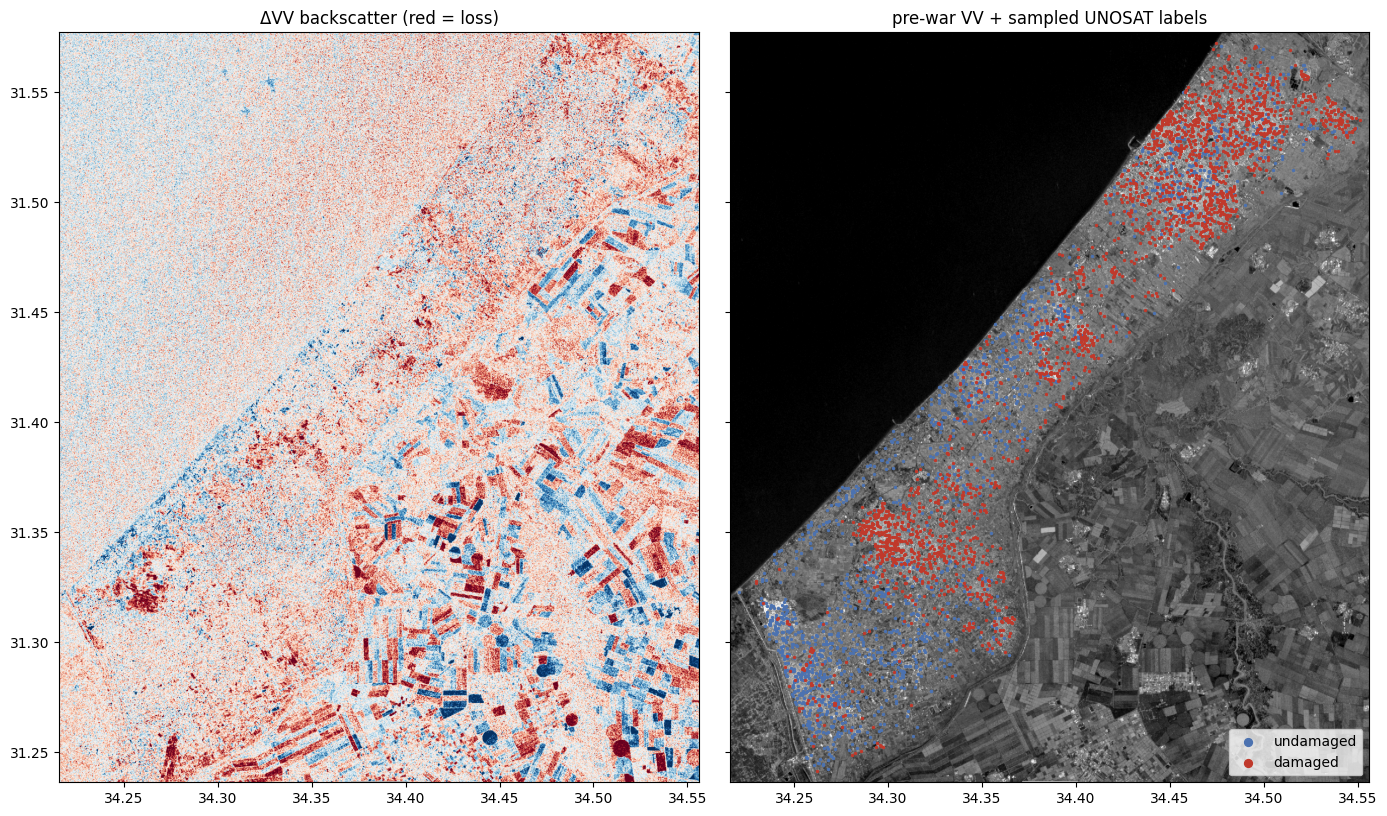

In [ ]:
with rasterio.open(RASTER_PATH) as src:
    scale = max(1, src.height // 1200)          # downsample for display
    out_shape = (src.count, src.height // scale, src.width // scale)
    arr = src.read(out_shape=out_shape).astype(np.float32)
    b = src.bounds
extent = [b.left, b.right, b.bottom, b.top]
dvv = arr[2] - arr[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
axes[0].imshow(dvv, cmap="RdBu", vmin=-6, vmax=6, extent=extent)
axes[0].set_title("ΔVV backscatter (red = loss)")

axes[1].imshow(arr[0], cmap="gray", vmin=-22, vmax=2, extent=extent)
sub = gdf.loc[keep_idx]
xs = sub["centroid"].apply(lambda p: p.x); ys = sub["centroid"].apply(lambda p: p.y)
cls = sub["class"].values
axes[1].scatter(xs[cls == 0], ys[cls == 0], s=2, c="#4C72B0", label="undamaged")
axes[1].scatter(xs[cls == 1], ys[cls == 1], s=2, c="#C0392B", label="damaged")
axes[1].set_title("pre-war VV + sampled UNOSAT labels")
axes[1].legend(markerscale=4, loc="lower right")
for ax in axes:
    ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(extent[2:]))))  # ~equal-area in lat/lon
plt.tight_layout(); plt.show()

## 3d. Sentinel-2 export + multimodal patch set

Adds an optical modality and the PWTT tabular features so three model classes can be
compared on **identical buildings**:

- **Sentinel-2** pre/post composites (B2/B3/B4/B8, all native 10 m), cloud-masked.
  `S2_SR_HARMONIZED` (surface reflectance) starts ~2017-03; for earlier dates the
  code falls back to `S2_HARMONIZED` (TOA) and says so.
- **PWTT features** `k50/k100/k150/max_change` + `area` as a tabular vector.
  `damage_pts` is **excluded** — it is the count of UNOSAT points used to *build*
  the label, i.e. pure leakage.

The multimodal extractor indexes each raster with its own transform and keeps only
buildings valid in **both** rasters, so every model in Section 5 trains and tests on
the same patch set. Caveat for the report: any model consuming the PWTT features is a
*fusion* result and cannot be described as "beating the PWTT baseline" — it uses the
baseline as an input.

In [ ]:
S2_PATH = f"gaza_s2_stack_{POST_DIRECTION}.tif"
S2_BANDS_10M = ["B2", "B3", "B4", "B8"]          # blue, green, red, NIR
TAB_FEATURES = ["k50", "k100", "k150", "max_change", "area"]   # NO damage_pts

def build_s2_composite(aoi, start, end, max_cloud=60):
    """Cloud-masked median composite; falls back to TOA when SR is unavailable."""
    import ee
    def mask_scl(img):                       # L2A
        scl = img.select("SCL")
        bad = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10))
        return img.updateMask(bad.Not())
    def mask_qa60(img):                      # L1C / TOA
        qa = img.select("QA60")
        clear = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        return img.updateMask(clear)
    for cid, mask_fn, lvl in [("COPERNICUS/S2_SR_HARMONIZED", mask_scl, "SR"),
                              ("COPERNICUS/S2_HARMONIZED", mask_qa60, "TOA")]:
        c = (ee.ImageCollection(cid).filterBounds(aoi).filterDate(start, end)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud)))
        n = c.size().getInfo()
        if n > 0:
            return c.map(mask_fn).select(S2_BANDS_10M).median(), n, lvl
    return None, 0, "none"

if not os.path.exists(S2_PATH):
    import ee, geemap
    try:
        ee.Initialize(project=GEE_PROJECT)
    except Exception:
        ee.Authenticate(); ee.Initialize(project=GEE_PROJECT)

    aoi = ee.Geometry.Rectangle(BBOX)
    war, label = ee.Date(WAR_START), ee.Date(LABEL_DATE)
    if POST_DIRECTION == "forward":
        po_s, po_e = label, label.advance(POST_MONTHS, "month")
    else:
        po_s, po_e = label.advance(-POST_MONTHS, "month"), label

    pre_o,  n_pre,  lvl_pre  = build_s2_composite(aoi, war.advance(-PRE_MONTHS, "month"), war)
    post_o, n_post, lvl_post = build_s2_composite(aoi, po_s, po_e)
    print(f"S2 scenes: {n_pre} pre ({lvl_pre}) / {n_post} post ({lvl_post})")
    if lvl_pre != lvl_post:
        print("WARNING: pre/post use different processing levels (TOA vs SR) — "
              "their difference is contaminated by atmosphere; force both to TOA "
              "if optical results matter.")
    stack = (pre_o.rename([f"pre_{b}" for b in S2_BANDS_10M])
                  .addBands(post_o.rename([f"post_{b}" for b in S2_BANDS_10M]))
                  .clip(aoi).toFloat())
    geemap.download_ee_image(stack, S2_PATH, region=aoi, scale=10, crs="EPSG:4326")
    print("exported", S2_PATH)
else:
    print(f"{S2_PATH} already exists — skipping GEE export")

S2 scenes: 127 pre (SR) / 12 post (SR)


/usr/local/lib/python3.12/dist-packages/geemap/common.py:12333: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


  0%|          |0/192 tiles [00:00<?]

exported gaza_s2_stack_forward.tif


In [ ]:
def extract_multimodal(sar_path, s2_path, gdf, patch=PATCH, tab_cols=TAB_FEATURES):
    """X (N, 12, p, p): ch 0-3 SAR [pre_VV, pre_VH, post_VV, post_VH] (dB),
    ch 4-11 optical [pre_B2..B8, post_B2..B8] (reflectance). Plus tab (N, n_tab).

    Each raster is indexed with its OWN transform (the grids need not align), and
    only buildings finite in BOTH rasters are kept -> every model sees the same set.
    np.isfinite (not isnan): S1 out-of-swath pixels are -inf in dB.
    """
    with rasterio.open(sar_path) as s:
        sar, inv_s, Hs, Ws = s.read().astype(np.float32), ~s.transform, s.height, s.width
    with rasterio.open(s2_path) as s:
        opt, inv_o, Ho, Wo = s.read().astype(np.float32), ~s.transform, s.height, s.width
    assert sar.shape[0] == 4 and opt.shape[0] == 8

    xs = gdf["centroid"].apply(lambda p: p.x).values
    ys = gdf["centroid"].apply(lambda p: p.y).values
    h = patch // 2
    def corners(inv):
        c, r = inv * (xs, ys)
        return np.round(r).astype(int) - h, np.round(c).astype(int) - h
    r_s, c_s = corners(inv_s); r_o, c_o = corners(inv_o)
    ok = ((r_s >= 0) & (c_s >= 0) & (r_s + patch <= Hs) & (c_s + patch <= Ws) &
          (r_o >= 0) & (c_o >= 0) & (r_o + patch <= Ho) & (c_o + patch <= Wo))

    Xl, keep = [], []
    idx = gdf.index.values
    for j in np.where(ok)[0]:
        a = sar[:, r_s[j]:r_s[j]+patch, c_s[j]:c_s[j]+patch]
        b = opt[:, r_o[j]:r_o[j]+patch, c_o[j]:c_o[j]+patch]
        if np.isfinite(a).all() and np.isfinite(b).all():
            Xl.append(np.concatenate([a, b], axis=0)); keep.append(idx[j])
    keep = np.array(keep)
    sub = gdf.loc[keep]
    tab = sub[tab_cols].to_numpy(np.float32)
    yv = sub["class"].to_numpy(int)
    if not np.isfinite(tab).all():
        n = int((~np.isfinite(tab)).any(axis=1).sum())
        print(f"  {n} rows with non-finite tabular features -> median-imputed")
        med = np.nanmedian(np.where(np.isfinite(tab), tab, np.nan), axis=0)
        tab = np.where(np.isfinite(tab), tab, med)
    print(f"kept {len(Xl)}/{len(gdf)} buildings | X (N,12,{patch},{patch}) | "
          f"tab {tab.shape} | {yv.mean()*100:.2f}% damaged")
    return np.stack(Xl), tab, yv, keep

X_mm, tab_all, y_mm, keep_mm = extract_multimodal(RASTER_PATH, S2_PATH, gdf)

kept 4000/4000 buildings | X (N,12,32,32) | tab (4000, 5) | 57.27% damaged


## 4. Spatial train / validation / test split + normalization

Three latitude bands: **train** (north), **validation** (middle band, for early
stopping and threshold selection), **test** (southern third — never touched during
training or model selection). The validation band sits *between* train and test so
it is spatially disjoint from both; a random validation split would leak through
spatial autocorrelation and make early stopping optimistic.

All normalization statistics (12 image channels + tabular features) come from the
training band only. `mu_sar`/`sd_sar` are the SAR-only slices, used by the transfer
section (other cities have no S2 export).

In [ ]:
lat_mm = gdf.loc[keep_mm, "centroid"].apply(lambda p: p.y).values
q_test, q_val = np.quantile(lat_mm, [0.33, 0.55])
test_mask  = lat_mm < q_test
val_mask   = (lat_mm >= q_test) & (lat_mm < q_val)
train_mask = lat_mm >= q_val

X_tr, tab_tr, y_tr = X_mm[train_mask], tab_all[train_mask], y_mm[train_mask]
X_va, tab_va, y_va = X_mm[val_mask],   tab_all[val_mask],   y_mm[val_mask]
X_te, tab_te, y_te = X_mm[test_mask],  tab_all[test_mask],  y_mm[test_mask]

mu = X_tr.mean(axis=(0, 2, 3), keepdims=True)          # (1,12,1,1)
sd = X_tr.std(axis=(0, 2, 3), keepdims=True) + 1e-6
X_tr, X_va, X_te = (X_tr - mu) / sd, (X_va - mu) / sd, (X_te - mu) / sd
mu_sar, sd_sar = mu[:, :4], sd[:, :4]                  # for cross-city transfer

tab_mu = tab_tr.mean(axis=0, keepdims=True)
tab_sd = tab_tr.std(axis=0, keepdims=True) + 1e-6
tab_tr, tab_va, tab_te = ((tab_tr - tab_mu) / tab_sd, (tab_va - tab_mu) / tab_sd,
                          (tab_te - tab_mu) / tab_sd)

keep_idx = keep_mm    # downstream cells (map, transfer) index gdf with keep_idx
for nm, yy in [("train", y_tr), ("val", y_va), ("test", y_te)]:
    print(f"{nm:5s} n={len(yy):6d}  damaged={yy.mean()*100:5.2f}%")

train n=  1800  damaged=75.00%
val   n=   880  damaged=51.48%
test  n=  1320  damaged=36.97%


## 5. Model zoo — three architectures, one training protocol

| Model | Input | Params (approx) | Question it answers |
|---|---|---|---|
| **Basic CNN** | SAR (4 ch) | ~25k | the from-scratch baseline |
| **Scaled CNN** | SAR (4 ch) | ~200k | does capacity help at this data scale? |
| **Multimodal** | SAR + S2 (12 ch) + PWTT tabular | ~400k | do extra modalities help? |

All three share the identical protocol: same spatially-disjoint splits, same
augmentation (flips/rot90 only — no brightness jitter, absolute backscatter *is* the
signal), same class-weighted loss, same early stopping on **validation PR-AUC** with
best-checkpoint restore, same per-model validation-selected threshold. That way the
table in Section 6 compares architectures, not training recipes.

The multimodal row consumes PWTT's own statistic, so it is a fusion result — the
PWTT-comparable rows are the two SAR-only models.

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (precision_recall_fscore_support, average_precision_score,
                             roc_auc_score, precision_recall_curve)

torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------- architectures -------------------------------
class SmallChangeCNN(nn.Module):
    """The original ~25k-parameter baseline (SAR channels only)."""
    def __init__(self, in_ch=4):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(in_ch, 16), block(16, 32), block(32, 64))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x, tab=None):
        return self.head(self.features(x)).squeeze(1)


class ResBlock(nn.Module):
    """Pre-activation residual block."""
    def __init__(self, cin, cout, stride=1, p_drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(cin)
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.drop = nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity()
        self.short = (nn.Identity() if (stride == 1 and cin == cout)
                      else nn.Conv2d(cin, cout, 1, stride=stride, bias=False))
    def forward(self, x):
        h = F.relu(self.bn1(x))
        out = self.conv1(h)
        out = self.drop(self.conv2(F.relu(self.bn2(out))))
        return out + self.short(h)


class CenterWeightedPool(nn.Module):
    """[Gaussian-center pool || GAP]: the label describes the CENTER building,
    but context helps — give the head both."""
    def __init__(self, sigma_frac=0.25):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.tensor(float(np.log(sigma_frac))))
    def forward(self, x):
        n, c, h, w = x.shape
        ys = torch.linspace(-1, 1, h, device=x.device).view(h, 1)
        xs = torch.linspace(-1, 1, w, device=x.device).view(1, w)
        sigma = self.log_sigma.exp().clamp(0.05, 2.0)
        wgt = torch.exp(-(ys ** 2 + xs ** 2) / (2 * sigma ** 2))
        wgt = (wgt / wgt.sum()).view(1, 1, h, w)
        return torch.cat([(x * wgt).sum(dim=(2, 3)), x.mean(dim=(2, 3))], dim=1)


def _tower(cin, width, depth, p_drop):
    layers, c = [nn.Conv2d(cin, width, 3, padding=1, bias=False)], width
    for si, nb in enumerate(depth):
        cout = width * (2 ** si)
        for bi in range(nb):
            layers.append(ResBlock(c, cout, stride=2 if bi == 0 else 1, p_drop=p_drop))
            c = cout
    return nn.Sequential(*layers, nn.BatchNorm2d(c), nn.ReLU()), c


class ScaledChangeCNN(nn.Module):
    """Residual tower + center-weighted pooling. SAR channels only."""
    def __init__(self, in_ch=4, width=32, depth=(2, 2, 2), p_drop=0.1, head_drop=0.4):
        super().__init__()
        self.tower, c = _tower(in_ch, width, depth, p_drop)
        self.pool = CenterWeightedPool()
        self.head = nn.Sequential(nn.Dropout(head_drop), nn.Linear(2 * c, 128),
                                  nn.ReLU(), nn.Dropout(head_drop / 2), nn.Linear(128, 1))
    def forward(self, x, tab=None):
        return self.head(self.pool(self.tower(x))).squeeze(1)


class MultiModalChangeCNN(nn.Module):
    """Separate towers for SAR (dB) and optical (reflectance) — their statistics
    and texture differ too much to share first-layer filters — plus an MLP for
    the PWTT tabular features."""
    def __init__(self, sar_ch=4, opt_ch=8, n_tab=5, width=32, depth=(2, 2, 2),
                 p_drop=0.1, head_drop=0.4):
        super().__init__()
        self.sar_ch, self.opt_ch, self.n_tab = sar_ch, opt_ch, n_tab
        self.sar_tower, c1 = _tower(sar_ch, width, depth, p_drop)
        self.opt_tower, c2 = _tower(opt_ch, width, depth, p_drop)
        self.sar_pool, self.opt_pool = CenterWeightedPool(), CenterWeightedPool()
        feat = 2 * c1 + 2 * c2
        if n_tab > 0:
            self.tab = nn.Sequential(nn.Linear(n_tab, 32), nn.ReLU(),
                                     nn.Linear(32, 32), nn.ReLU())
            feat += 32
        self.head = nn.Sequential(nn.Dropout(head_drop), nn.Linear(feat, 128),
                                  nn.ReLU(), nn.Dropout(head_drop / 2), nn.Linear(128, 1))
    def forward(self, x, tab=None):
        fs = [self.sar_pool(self.sar_tower(x[:, :self.sar_ch])),
              self.opt_pool(self.opt_tower(x[:, self.sar_ch:self.sar_ch + self.opt_ch]))]
        if self.n_tab > 0:
            fs.append(self.tab(tab))
        return self.head(torch.cat(fs, dim=1)).squeeze(1)


# ------------------------------ data + training ------------------------------
class MMDataset(torch.utils.data.Dataset):
    """Yields (image, tab, y). Flips/rot90 in train mode; tab passes through."""
    def __init__(self, X, tab, y, chans, train=False):
        self.X, self.tab, self.y, self.chans, self.train = X, tab, y, chans, train
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i, self.chans])
        if self.train:
            if torch.rand(1).item() < 0.5: x = torch.flip(x, dims=[2])
            if torch.rand(1).item() < 0.5: x = torch.flip(x, dims=[1])
            k = int(torch.randint(0, 4, (1,)).item())
            if k: x = torch.rot90(x, k, dims=[1, 2])
        return (x.contiguous(), torch.from_numpy(self.tab[i]),
                torch.tensor(float(self.y[i])))


def train_model(name, build_fn, chans, uses_tab, max_epochs=200, patience=20,
                lr=3e-4, batch=128, verbose_every=1):
    """One protocol for every model: AdamW + cosine, pos-weighted BCE, early
    stopping on val PR-AUC, best-checkpoint restore. Returns a result dict."""
    torch.manual_seed(SEED)
    model = build_fn().to(device)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"\n===== {name} ({n_par:,} params, chans={chans}) =====")

    tr_dl = DataLoader(MMDataset(X_tr, tab_tr, y_tr, chans, train=True),
                       batch_size=batch, shuffle=True, drop_last=True)
    va_dl = DataLoader(MMDataset(X_va, tab_va, y_va, chans), batch_size=256)
    te_dl = DataLoader(MMDataset(X_te, tab_te, y_te, chans), batch_size=256)

    pos_weight = torch.tensor([(len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)],
                              dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    use_amp = device == "cuda"
    scaler = torch.amp.GradScaler(device, enabled=use_amp)

    def fwd(xb, tb):
        return model(xb, tb) if uses_tab else model(xb)

    @torch.no_grad()
    def run_eval(dl, y_true):
        model.eval()
        logits = []
        for xb, tb, _ in dl:
            with torch.amp.autocast(device, enabled=use_amp):
                logits.append(fwd(xb.to(device), tb.to(device)).float().cpu())
        logits = torch.cat(logits)
        probs = torch.sigmoid(logits).numpy()
        return average_precision_score(y_true, probs), probs

    best_ap, best_epoch, best_state, bad, history = -np.inf, -1, None, 0, []
    for ep in range(1, max_epochs + 1):
        model.train(); tot, seen = 0.0, 0
        for xb, tb, yb in tr_dl:
            xb, tb, yb = xb.to(device), tb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device, enabled=use_amp):
                loss = crit(fwd(xb, tb), yb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update()
            tot += loss.item() * len(yb); seen += len(yb)
        sched.step()

        va_ap, _ = run_eval(va_dl, y_va)
        history.append((ep, tot / seen, va_ap))
        if va_ap > best_ap + 1e-4:
            best_ap, best_epoch, bad = va_ap, ep, 0
            best_state = copy.deepcopy(model.state_dict())
            flag = "  *best*"
        else:
            bad += 1; flag = ""
        if ep % verbose_every == 0:
            print(f"epoch {ep:3d}  train {tot/seen:.4f}  val PR-AUC {va_ap:.4f}{flag}")
        if bad >= patience:
            print(f"early stop at epoch {ep} (best {best_epoch})")
            break

    model.load_state_dict(best_state)
    _, va_probs = run_eval(va_dl, y_va)
    _, te_probs = run_eval(te_dl, y_te)

    # per-model threshold, chosen on VALIDATION only
    prec, rec, thr = precision_recall_curve(y_va, va_probs)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    val_thr = float(thr[np.argmax(f1)])
    print(f"best epoch {best_epoch}: val PR-AUC {best_ap:.4f}, "
          f"val-selected threshold {val_thr:.3f}")

    return dict(name=name, model=model, n_params=n_par, history=np.array(history),
                best_epoch=best_epoch, val_ap=best_ap, val_thr=val_thr,
                va_probs=va_probs, te_probs=te_probs, uses_tab=uses_tab, chans=chans)

In [ ]:
SAR = slice(0, 4)
ALL12 = slice(0, 12)

MODEL_SPECS = {
    "Basic CNN (SAR)": dict(
        build_fn=lambda: SmallChangeCNN(in_ch=4), chans=SAR, uses_tab=False),
    "Scaled CNN (SAR)": dict(
        build_fn=lambda: ScaledChangeCNN(in_ch=4, width=32, depth=(2, 2, 2)),
        chans=SAR, uses_tab=False),
    "Multimodal (SAR+S2+PWTT)": dict(
        build_fn=lambda: MultiModalChangeCNN(n_tab=len(TAB_FEATURES),
                                             width=32, depth=(2, 2, 2)),
        chans=ALL12, uses_tab=True),
}

runs = {}
for name, spec in MODEL_SPECS.items():
    runs[name] = train_model(name, **spec)


===== Basic CNN (SAR) (24,017 params, chans=slice(0, 4, None)) =====
epoch   1  train 0.3533  val PR-AUC 0.6131  *best*
epoch   2  train 0.3436  val PR-AUC 0.6931  *best*
epoch   3  train 0.3310  val PR-AUC 0.7096  *best*
epoch   4  train 0.3291  val PR-AUC 0.7630  *best*
epoch   5  train 0.3258  val PR-AUC 0.7132
epoch   6  train 0.3190  val PR-AUC 0.7483
epoch   7  train 0.3120  val PR-AUC 0.7086
epoch   8  train 0.3106  val PR-AUC 0.6956
epoch   9  train 0.3119  val PR-AUC 0.7481
epoch  10  train 0.3004  val PR-AUC 0.7542
epoch  11  train 0.3084  val PR-AUC 0.7143
epoch  12  train 0.2998  val PR-AUC 0.7698  *best*
epoch  13  train 0.2995  val PR-AUC 0.7450
epoch  14  train 0.2948  val PR-AUC 0.7683
epoch  15  train 0.2995  val PR-AUC 0.7501
epoch  16  train 0.2912  val PR-AUC 0.7836  *best*
epoch  17  train 0.2967  val PR-AUC 0.7383
epoch  18  train 0.2942  val PR-AUC 0.7520
epoch  19  train 0.2895  val PR-AUC 0.8002  *best*
epoch  20  train 0.2976  val PR-AUC 0.8016  *best*
epoch 

## 6. Comparison on the held-out south

For each model: metrics at its own **validation-selected threshold** (chosen without
touching test), plus threshold-free PR-AUC / ROC-AUC. The PWTT `max_change @ 3.3` row
is the external baseline — comparable to the two SAR-only models, **not** to the
multimodal one (which consumes PWTT's statistic as an input).

In [ ]:
PWTT_THRESHOLD = 3.3   # detect_damage() default in the PWTT library

def binary_metrics(y_true, score, thresh):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, (score >= thresh).astype(int), average="binary", zero_division=0)
    return dict(P=p, R=r, F1=f1, PR_AUC=average_precision_score(y_true, score),
                ROC_AUC=roc_auc_score(y_true, score))

mc_te = gdf.loc[keep_idx, "max_change"].values[test_mask]

results = {}
for name, r in runs.items():
    results[f"{name} @ {r['val_thr']:.2f}"] = binary_metrics(y_te, r["te_probs"],
                                                             r["val_thr"])
    results[f"{name} @ {r['val_thr']:.2f}"]["params"] = r["n_params"]
    results[f"{name} @ {r['val_thr']:.2f}"]["best_ep"] = r["best_epoch"]
results[f"PWTT max_change @ {PWTT_THRESHOLD}"] = binary_metrics(y_te, mc_te,
                                                                PWTT_THRESHOLD)
res_df = pd.DataFrame(results).T
display(res_df.round(3))
print(f"test prevalence: {y_te.mean():.4f}  (n={len(y_te)})")

,P,R,F1,PR_AUC,ROC_AUC,params,best_ep
Basic CNN (SAR) @ 0.23,0.625,0.764,0.688,0.731,0.819,24017.0,94.0
Scaled CNN (SAR) @ 0.15,0.486,0.881,0.627,0.689,0.791,729282.0,9.0
Multimodal (SAR+S2+PWTT) @ 0.17,0.499,0.939,0.652,0.741,0.836,1464803.0,11.0
PWTT max_change @ 3.3,0.596,0.529,0.560,0.592,0.715,NaN,NaN


test prevalence: 0.3697  (n=1320)


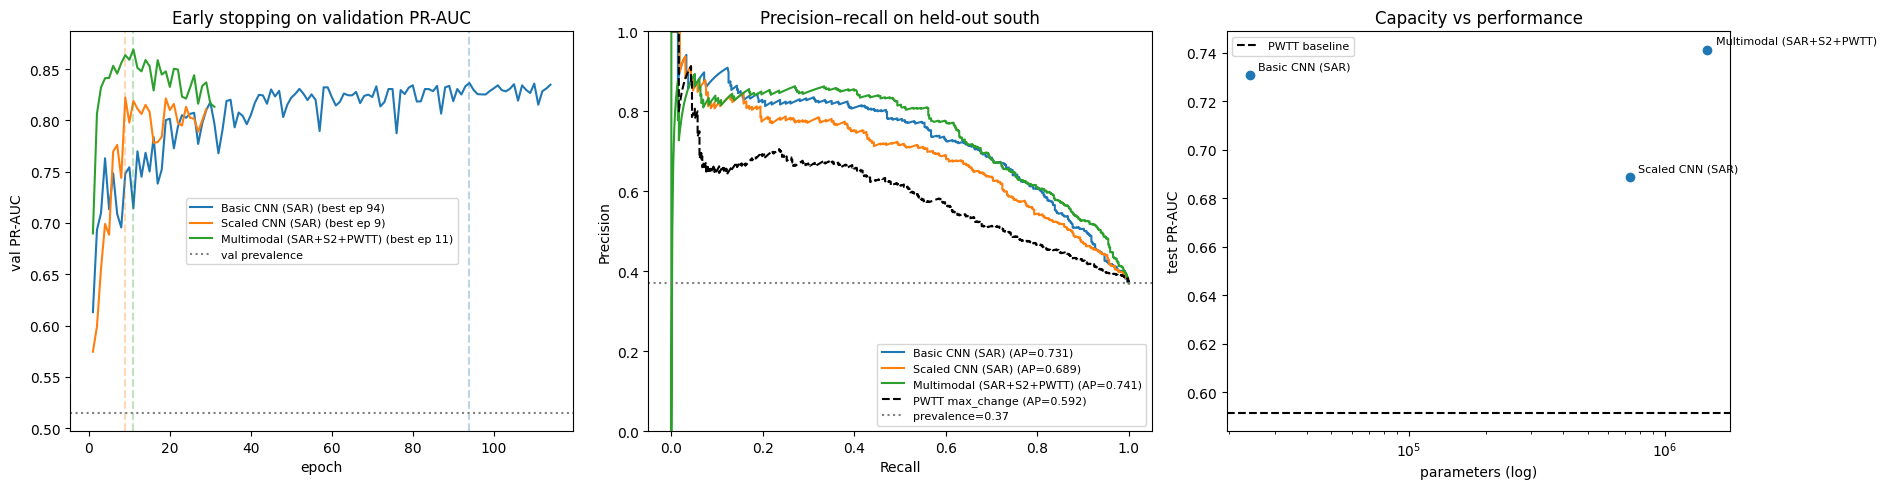

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (1) training curves: val PR-AUC per epoch, best epoch marked
for name, r in runs.items():
    h = r["history"]
    axes[0].plot(h[:, 0], h[:, 2], label=f"{name} (best ep {r['best_epoch']})")
    axes[0].axvline(r["best_epoch"], ls="--", alpha=0.3,
                    color=axes[0].lines[-1].get_color())
axes[0].axhline(y_va.mean(), color="gray", ls=":", label="val prevalence")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val PR-AUC")
axes[0].set_title("Early stopping on validation PR-AUC"); axes[0].legend(fontsize=8)

# (2) PR curves on test
for name, r in runs.items():
    pr, rc, _ = precision_recall_curve(y_te, r["te_probs"])
    axes[1].plot(rc, pr,
                 label=f"{name} (AP={average_precision_score(y_te, r['te_probs']):.3f})")
pr, rc, _ = precision_recall_curve(y_te, mc_te)
axes[1].plot(rc, pr, "--", color="k",
             label=f"PWTT max_change (AP={average_precision_score(y_te, mc_te):.3f})")
axes[1].axhline(y_te.mean(), color="gray", ls=":",
                label=f"prevalence={y_te.mean():.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_ylim(0, 1)
axes[1].set_title("Precision–recall on held-out south"); axes[1].legend(fontsize=8)

# (3) PR-AUC vs parameter count
names = list(runs)
aps = [average_precision_score(y_te, runs[n]["te_probs"]) for n in names]
pars = [runs[n]["n_params"] for n in names]
axes[2].scatter(pars, aps)
for n, x_, y_ in zip(names, pars, aps):
    axes[2].annotate(n, (x_, y_), textcoords="offset points", xytext=(6, 4),
                     fontsize=8)
axes[2].axhline(average_precision_score(y_te, mc_te), color="k", ls="--",
                label="PWTT baseline")
axes[2].set_xscale("log"); axes[2].set_xlabel("parameters (log)")
axes[2].set_ylabel("test PR-AUC"); axes[2].set_title("Capacity vs performance")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# ---- Backward compatibility for the map (6b) and transfer (Section 8) cells ----
# The transfer cities have SAR exports only, so cross-city transfer MUST use a
# SAR-only model. We hand it the scaled SAR model (swap for "Basic CNN (SAR)" to
# transfer the baseline instead), plus the SAR slice of the normalization stats.
TRANSFER_MODEL = "Scaled CNN (SAR)"
model = runs[TRANSFER_MODEL]["model"]
probs = runs[TRANSFER_MODEL]["te_probs"]      # used by the 6b map + Section 8
mu, sd = mu_sar, sd_sar                       # 4-channel stats for city transfer
print(f"downstream cells use: {TRANSFER_MODEL} "
      f"(test PR-AUC {average_precision_score(y_te, probs):.3f})")

downstream cells use: Scaled CNN (SAR) (test PR-AUC 0.689)


## 6b. Interactive GEE map — explore the imagery and predictions  *(optional)*

A live split map: pre-war VV on the left, post VV on the right, so you can swipe
across neighborhoods and watch structure vanish. Extra toggleable layers: the ΔVV
change composite, the sampled UNOSAT labels, and the CNN's predictions on the
held-out south. Tiles render server-side in GEE, so this costs nothing beyond the
earlier authentication.

Set `SHOW_GEE_MAP = True` to run (needs `ee` initialized; re-runs the cheap orbit
query but downloads nothing).

In [ ]:
SHOW_GEE_MAP = False

if SHOW_GEE_MAP:
    import ee, geemap, matplotlib

    try:
        ee.Initialize(project=GEE_PROJECT)
    except Exception:
        ee.Authenticate(); ee.Initialize(project=GEE_PROJECT)

    have_preds = all(v in globals() for v in ("probs", "test_mask", "y_te"))
    if not have_preds:
        print("NOTE: no predictions in memory — run Sections 4-6 first, then re-run "
              "this cell. Showing imagery + labels only.")

    aoi = ee.Geometry.Rectangle(BBOX)
    war, label = ee.Date(WAR_START), ee.Date(LABEL_DATE)
    if POST_DIRECTION == "forward":
        s2_post_start, s2_post_end = label, label.advance(POST_MONTHS, "month")
    else:
        s2_post_start, s2_post_end = label.advance(-POST_MONTHS, "month"), label

    # ---- Sentinel-2 RGB composites ----------------------------------------
    # SCL-based masking: 3=shadow, 8/9=cloud, 10=cirrus. Self-contained (no join
    # against S2_CLOUD_PROBABILITY). PWTT's _build_s2_collection() adds
    # s2cloudless + shadow projection if you want the stricter version.
    def s2_rgb(start, end, max_cloud=40):
        def mask_scl(img):
            scl = img.select("SCL")
            bad = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10))
            return img.updateMask(bad.Not())
        col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
               .filterBounds(aoi).filterDate(start, end)
               .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
               .map(mask_scl))
        n = col.size().getInfo()
        return col.select(["B4", "B3", "B2"]).median().clip(aoi), n

    pre_rgb,  n_pre  = s2_rgb(war.advance(-PRE_MONTHS, "month"), war)
    post_rgb, n_post = s2_rgb(s2_post_start, s2_post_end)
    print(f"Sentinel-2 scenes: {n_pre} pre / {n_post} post")
    if n_post == 0:
        print("  -> no usable post scenes; widen POST_MONTHS or raise max_cloud")

    rgb_vis = {"min": 0, "max": 3000, "gamma": 1.3}   # SR reflectance x10000

    m = geemap.Map(center=[(BBOX[1] + BBOX[3]) / 2, (BBOX[0] + BBOX[2]) / 2],
                   zoom=12, basemap="SATELLITE")     # high-res (undated) reference
    m.split_map(geemap.ee_tile_layer(pre_rgb,  rgb_vis, "Sentinel-2 RGB — pre-war"),
                geemap.ee_tile_layer(post_rgb, rgb_vis, "Sentinel-2 RGB — post"))

    # SAR change kept as an optional overlay
    pre_s1, post_s1, _, _ = build_s1_composites(verbose=False)
    m.addLayer(post_s1.select("VV").subtract(pre_s1.select("VV")).clip(aoi),
               {"min": -6, "max": 6, "palette": ["b2182b", "f7f7f7", "2166ac"]},
               "ΔVV SAR (red = backscatter loss)", shown=False)

    # ---- Building footprints colored by CNN prediction ---------------------
    cmap = matplotlib.colormaps["RdYlGn_r"]
    to_hex = lambda p: matplotlib.colors.to_hex(cmap(float(p)))

    def add_polys(rows, colors, name, opacity=0.75, weight=1, zoom=False, shown=True):
            if len(rows) == 0:
                print(f"  (skipped '{name}': 0 footprints)")
                return
            # MUST drop 'centroid' — a second geometry column raises
            # "TypeError: Object of type Point is not JSON serializable" on to_json()
            viz = rows[["geometry"]].copy()
            viz["color"] = colors
            # NOTE: add_gdf has no `shown` argument (addLayer does). Add, then toggle
            # visibility on the ipyleaflet layer, which geemap names from layer_name.
            m.add_gdf(viz, layer_name=name, zoom_to_layer=zoom, info_mode=None,
                      style_callback=lambda f: {
                          "color": f["properties"]["color"],
                          "fillColor": f["properties"]["color"],
                          "weight": weight, "fillOpacity": opacity})
            if not shown:
                for lyr in m.layers:
                    if getattr(lyr, "name", None) == name:
                        lyr.visible = False
                        break
            print(f"  layer '{name}': {len(viz)} footprints")

    sub = gdf.loc[keep_idx]

    if have_preds:
        te = sub.iloc[np.where(test_mask)[0]].copy()
        te["prob"] = probs
        te["correct"] = ((probs >= 0.5).astype(int) == y_te)

        add_polys(te, [to_hex(p) for p in te["prob"]],
                  "CNN P(damaged) — continuous", zoom=True)
        add_polys(te[~te["correct"]], "#000000",
                  "CNN misclassified @0.5", opacity=0.0, weight=2, shown=False)
        try:
            m.add_colorbar({"min": 0, "max": 1,
                            "palette": [to_hex(v) for v in np.linspace(0, 1, 9)]},
                           label="CNN P(damaged)")
        except Exception as e:
            print("  (colorbar unavailable:", e, ")")

    # Ground truth, off by default — it overlaps the prediction polygons exactly
    add_polys(sub[sub["class"] == 1], "#C0392B", "UNOSAT label: damaged",
              shown=not have_preds)
    add_polys(sub[sub["class"] == 0], "#4C72B0", "UNOSAT label: undamaged",
              shown=not have_preds)

    m.add_layer_control()
    print("Toggle layers from the layers icon in the top-right corner.")
    display(m)

In [ ]:
# ============ Section 8: transfer the Gaza-trained model to Syria ============
# Label dates are the authoritative ones from the PWTT benchmark table.
# war_start values are MY choices (PWTT doesn't publish theirs) — see notes below.
TRANSFER_CITIES = {
    "Raqqa":  dict(date="20171021", war_start="2017-06-06"),  # SDF offensive begins
    "Aleppo": dict(date="20160918", war_start="2016-07-01"),  # final siege begins
}
S1_EARLIEST = "2014-10-01"   # Sentinel-1A IW GRD becomes routinely available

def city_raster_path(city):
    return f"{city.lower()}_s1_stack_{POST_DIRECTION}.tif"

def build_s1_composites_for(bbox, war_start, label_date, verbose=True):
    """Generalized version of build_s1_composites() — explicit dates/bbox."""
    import ee
    aoi = ee.Geometry.Rectangle(bbox)
    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi)
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
          .select(["VV", "VH"]))

    war, label = ee.Date(war_start), ee.Date(label_date)
    pre_start, pre_end = war.advance(-PRE_MONTHS, "month"), war
    if POST_DIRECTION == "forward":
        post_start, post_end = label, label.advance(POST_MONTHS, "month")
    else:
        post_start, post_end = label.advance(-POST_MONTHS, "month"), label

    if pre_start.format("YYYY-MM-dd").getInfo() < S1_EARLIEST:
        print(f"  WARNING: pre-window starts before {S1_EARLIEST} — Sentinel-1 has no "
              f"data there. Push war_start later or shorten PRE_MONTHS.")

    def orbit_counts(a, b):
        h = (s1.filterDate(a, b)
               .aggregate_histogram("relativeOrbitNumber_start").getInfo())
        return {int(float(k)): int(v) for k, v in h.items()}

    pre_c, post_c = orbit_counts(pre_start, pre_end), orbit_counts(post_start, post_end)
    shared = set(pre_c) & set(post_c)
    if not shared:
        raise RuntimeError(f"No orbit covers both windows.\npre={pre_c}\npost={post_c}")
    best = max(shared, key=lambda o: (min(pre_c[o], post_c[o]), post_c[o]))
    if verbose:
        print(f"  orbits pre={pre_c} post={post_c} -> {best} "
              f"({pre_c[best]} pre / {post_c[best]} post)")
    s1 = s1.filter(ee.Filter.eq("relativeOrbitNumber_start", best))
    return (s1.filterDate(pre_start, pre_end).median(),
            s1.filterDate(post_start, post_end).median(), aoi, best)


def export_city_stack(city, cfg, n_sample=N_SAMPLE):
    """Load footprints, sample, export the matching 4-band SAR stack if absent."""
    import ee, geemap
    fp = os.path.join(DATA_DIR, f"{city}_{cfg['date']}_1_footprints.csv")
    g = load_footprints(fp)
    print(f"{city}: {len(g):,} footprints, {g['class'].mean()*100:.1f}% damaged")
    if len(g) > n_sample:
        g = g.sample(n_sample, random_state=SEED)
    g = g.copy()
    g["centroid"] = g.geometry.to_crs(3857).centroid.to_crs(4326)

    minx, miny, maxx, maxy = g.total_bounds
    bbox = [minx - 0.005, miny - 0.005, maxx + 0.005, maxy + 0.005]

    rp = city_raster_path(city)
    if not os.path.exists(rp):
        pre, post, aoi, _ = build_s1_composites_for(
            bbox, cfg["war_start"], f"{cfg['date'][:4]}-{cfg['date'][4:6]}-{cfg['date'][6:]}")
        stack = (pre.rename(["pre_VV", "pre_VH"])
                    .addBands(post.rename(["post_VV", "post_VH"])).clip(aoi).toFloat())
        geemap.download_ee_image(stack, rp, region=aoi, scale=10, crs="EPSG:4326")
        print(f"  exported {rp}")
    else:
        print(f"  {rp} exists — skipping export")
    return g, bbox


import ee
try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=GEE_PROJECT)

city_data = {}
for city, cfg in TRANSFER_CITIES.items():
    g, bbox = export_city_stack(city, cfg)
    Xc, yc, kc = extract_patches(city_raster_path(city), g)
    print(f"  patches: {Xc.shape}, {yc.mean()*100:.1f}% damaged\n")
    city_data[city] = dict(gdf=g, X=Xc, y=yc, keep=kc)

Raqqa: 24,689 footprints, 45.4% damaged
  orbits pre={116: 31, 123: 46} post={116: 6, 123: 4} -> 116 (31 pre / 6 post)


  0%|          |0/8 tiles [00:00<?]

  exported raqqa_s1_stack_forward.tif
  patches: (4000, 4, 32, 32), 45.8% damaged

Aleppo: 65,870 footprints, 30.8% damaged
  orbits pre={116: 31, 14: 29, 21: 26} post={116: 4, 14: 4, 21: 4} -> 116 (31 pre / 4 post)


  0%|          |0/32 tiles [00:00<?]

  exported aleppo_s1_stack_forward.tif
  patches: (4000, 4, 32, 32), 30.4% damaged



Raqqa: mean backscatter shift vs Gaza = 0.87 dB
Aleppo: mean backscatter shift vs Gaza = 1.69 dB


,P,R,F1,PR_AUC,ROC_AUC,prevalence,n
Gaza (held-out south),0.769,0.369,0.499,0.689,0.791,0.370,1320.0
Raqqa — Gaza norm,0.643,0.534,0.583,0.621,0.689,0.458,4000.0
Raqqa — target norm,0.630,0.336,0.438,0.581,0.654,0.458,4000.0
Raqqa — PWTT @3.3,0.625,0.481,0.544,0.613,0.675,0.458,4000.0
Aleppo — Gaza norm,0.551,0.201,0.295,0.440,0.610,0.304,4000.0
Aleppo — target norm,0.618,0.052,0.096,0.420,0.618,0.304,4000.0
Aleppo — PWTT @3.3,0.476,0.334,0.392,0.447,0.664,0.304,4000.0


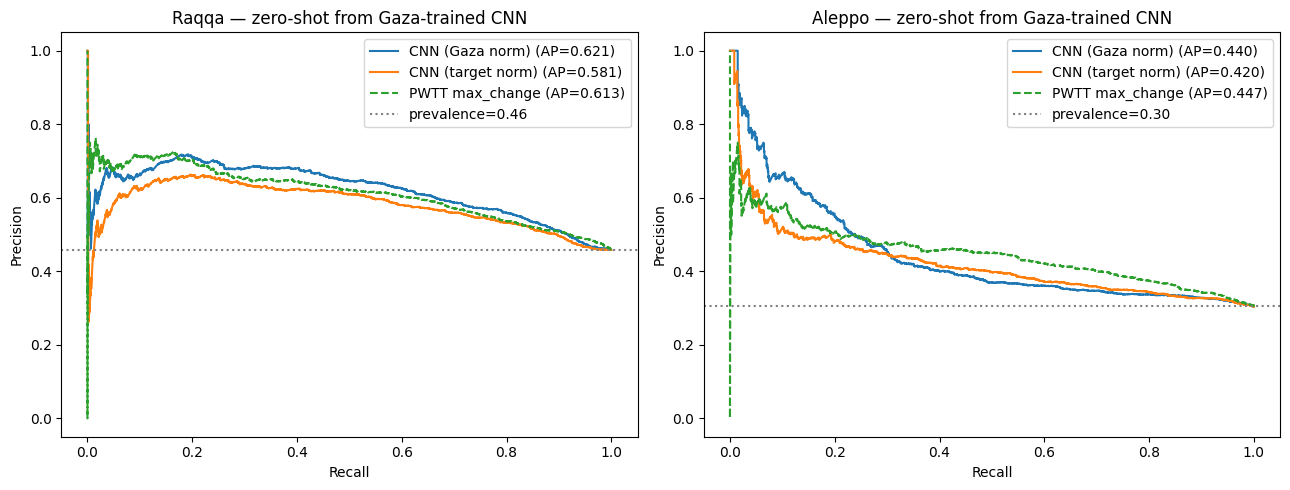

In [ ]:
@torch.no_grad()
def predict_probs(X_norm, bs=256):
    model.eval()
    return np.concatenate([
        torch.sigmoid(model(torch.from_numpy(X_norm[i:i+bs]).to(device))).cpu().numpy()
        for i in range(0, len(X_norm), bs)])

def metrics(y_true, score, thresh):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, (score >= thresh).astype(int), average="binary", zero_division=0)
    return dict(P=p, R=r, F1=f1, PR_AUC=average_precision_score(y_true, score),
                ROC_AUC=roc_auc_score(y_true, score), prevalence=y_true.mean(),
                n=len(y_true))

rows, curves = {}, {}

# Gaza's own held-out south, for reference
rows["Gaza (held-out south)"] = metrics(y_te, probs, 0.5)
curves["Gaza south"] = (y_te, probs)

for city, d in city_data.items():
    Xc, yc = d["X"], d["y"]
    # (a) pure transfer — Gaza's normalization statistics, unchanged
    p_src = predict_probs((Xc - mu) / sd)
    # (b) target normalization — recompute per-city stats (cheap domain adaptation,
    #     uses no labels, so it is still a legitimate zero-shot transfer)
    mu_t = Xc.mean(axis=(0, 2, 3), keepdims=True)
    sd_t = Xc.std(axis=(0, 2, 3), keepdims=True) + 1e-6
    p_tgt = predict_probs((Xc - mu_t) / sd_t)
    mc = d["gdf"].loc[d["keep"], "max_change"].values

    rows[f"{city} — Gaza norm"]    = metrics(yc, p_src, 0.5)
    rows[f"{city} — target norm"]  = metrics(yc, p_tgt, 0.5)
    rows[f"{city} — PWTT @{PWTT_THRESHOLD}"] = metrics(yc, mc, PWTT_THRESHOLD)
    curves[f"{city} (target norm)"] = (yc, p_tgt)
    d["p_src"], d["p_tgt"], d["mc"] = p_src, p_tgt, mc

    print(f"{city}: mean backscatter shift vs Gaza = "
          f"{np.abs(mu_t.ravel() - mu.ravel()).mean():.2f} dB")

display(pd.DataFrame(rows).T.round(3))

# PR curves, one panel per city
fig, axes = plt.subplots(1, len(city_data), figsize=(6.5 * len(city_data), 5))
axes = np.atleast_1d(axes)
for ax, (city, d) in zip(axes, city_data.items()):
    for score, lab, style in [(d["p_src"], "CNN (Gaza norm)", "-"),
                              (d["p_tgt"], "CNN (target norm)", "-"),
                              (d["mc"], "PWTT max_change", "--")]:
        pr, rc, _ = precision_recall_curve(d["y"], score)
        ax.plot(rc, pr, style,
                label=f"{lab} (AP={average_precision_score(d['y'], score):.3f})")
    ax.axhline(d["y"].mean(), color="gray", ls=":",
               label=f"prevalence={d['y'].mean():.2f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{city} — zero-shot from Gaza-trained CNN"); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
def export_city_stack(city, cfg, n_sample=N_SAMPLE):
    """Load footprints, optionally sample, export the matching 4-band SAR stack.

    n_sample=None -> use every footprint (needed for low-prevalence cities).
    """
    import ee, geemap
    fp = os.path.join(DATA_DIR, f"{city}_{cfg['date']}_1_footprints.csv")
    g = load_footprints(fp)
    print(f"{city}: {len(g):,} footprints, {g['class'].mean()*100:.2f}% damaged")

    if n_sample is not None and len(g) > n_sample:
        g = g.sample(n_sample, random_state=SEED)
        print(f"  sampled {len(g):,} ({int(g['class'].sum())} positives)")
    else:
        print(f"  using all {len(g):,} ({int(g['class'].sum())} positives)")
    g = g.copy()
    g["centroid"] = g.geometry.to_crs(3857).centroid.to_crs(4326)

    minx, miny, maxx, maxy = g.total_bounds
    bbox = [minx - 0.005, miny - 0.005, maxx + 0.005, maxy + 0.005]

    rp = city_raster_path(city)
    if not os.path.exists(rp):
        d = cfg["date"]
        pre, post, aoi, _ = build_s1_composites_for(
            bbox, cfg["war_start"], f"{d[:4]}-{d[4:6]}-{d[6:]}")
        stack = (pre.rename(["pre_VV", "pre_VH"])
                    .addBands(post.rename(["post_VV", "post_VH"])).clip(aoi).toFloat())
        geemap.download_ee_image(stack, rp, region=aoi, scale=10, crs="EPSG:4326")
        print(f"  exported {rp}")
    else:
        print(f"  {rp} exists — skipping export")
    return g, bbox

UKRAINE_WAR_START = "2022-02-24"
TRANSFER_CITIES.update({
    "Mariupol": dict(date="20220512", war_start=UKRAINE_WAR_START, n_sample=None),
    "Irpin":    dict(date="20220331", war_start=UKRAINE_WAR_START, n_sample=None),
    "Bucha":    dict(date="20220331", war_start=UKRAINE_WAR_START, n_sample=None),
})

MIN_POSITIVES = 30   # below this, per-city precision/recall are noise

for city, cfg in TRANSFER_CITIES.items():
    if city in city_data:            # already prepared — skip
        continue
    try:
        g, bbox = export_city_stack(city, cfg, n_sample=cfg.get("n_sample", N_SAMPLE))
        Xc, yc, kc = extract_patches(city_raster_path(city), g)
        npos = int(yc.sum())
        print(f"  patches: {Xc.shape}, {yc.mean()*100:.2f}% damaged ({npos} positives)")
        if npos < MIN_POSITIVES:
            print(f"  WARNING: only {npos} positives — metrics will be unstable.")
        city_data[city] = dict(gdf=g, X=Xc, y=yc, keep=kc)
    except Exception as e:
        print(f"  FAILED {city}: {type(e).__name__}: {e}")
    print()

print("prepared:", sorted(city_data))

Mariupol: 18,446 footprints, 31.42% damaged
  using all 18,446 (5796 positives)
  orbits pre={116: 55, 43: 54, 94: 56} post={116: 3, 43: 2, 94: 3} -> 116 (55 pre / 3 post)


  0%|          |0/16 tiles [00:00<?]

  exported mariupol_s1_stack_forward.tif
  patches: (18446, 4, 32, 32), 31.42% damaged (5796 positives)

Irpin: 7,242 footprints, 11.28% damaged
  using all 7,242 (817 positives)
  orbits pre={160: 54, 36: 47, 87: 55} post={160: 2, 36: 3, 87: 2} -> 36 (47 pre / 3 post)


  0%|          |0/8 tiles [00:00<?]

  exported irpin_s1_stack_forward.tif
  patches: (7242, 4, 32, 32), 11.28% damaged (817 positives)

Bucha: 5,739 footprints, 1.60% damaged
  using all 5,739 (92 positives)
  orbits pre={160: 54, 36: 47, 87: 55} post={160: 2, 36: 3, 87: 2} -> 36 (47 pre / 3 post)


  0%|          |0/8 tiles [00:00<?]

  exported bucha_s1_stack_forward.tif
  patches: (5739, 4, 32, 32), 1.60% damaged (92 positives)

prepared: ['Aleppo', 'Bucha', 'Irpin', 'Mariupol', 'Raqqa']


usable: ['Aleppo', 'Bucha', 'Irpin', 'Raqqa']
F1-optimal threshold on Gaza held-out south: 0.244 (Gaza F1 = 0.667)

Irpin: prevalence 11.28%, CNN flags 1.8% at 0.5, 7.7% at 0.24
Bucha: prevalence 1.60%, CNN flags 0.3% at 0.5, 3.7% at 0.24


,P,R,F1,PR_AUC,ROC_AUC,prevalence,n
Irpin — CNN @0.5,0.3308,0.0539,0.0926,0.2020,0.6400,0.1128,7242.0
Irpin — CNN @0.24 (Gaza-selected),0.2837,0.1934,0.2300,0.2020,0.6400,0.1128,7242.0
Irpin — PWTT @3.3,0.3054,0.5704,0.3978,0.3300,0.7828,0.1128,7242.0
Bucha — CNN @0.5,0.1176,0.0217,0.0367,0.0307,0.6475,0.0160,5739.0
Bucha — CNN @0.24 (Gaza-selected),0.0381,0.0870,0.0530,0.0307,0.6475,0.0160,5739.0
Bucha — PWTT @3.3,0.1312,0.4565,0.2039,0.1441,0.7951,0.0160,5739.0


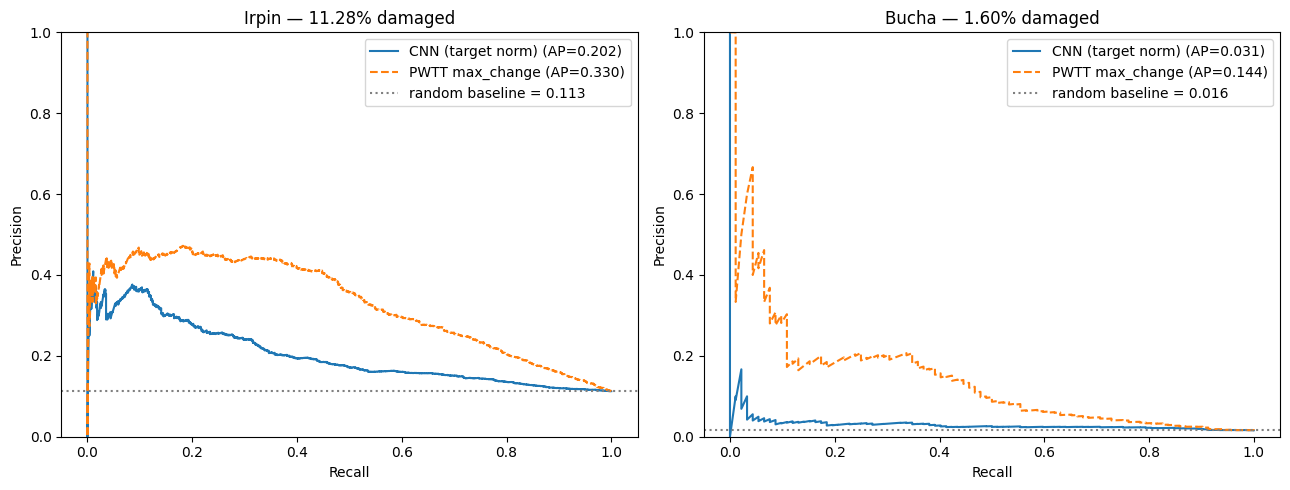

In [ ]:
WANTED = ["Irpin", "Bucha"]
UK_CITIES = [c for c in WANTED if c in city_data]
missing = [c for c in WANTED if c not in city_data]
if missing:
    print(f"NOTE: not prepared, skipping {missing} — re-run the prep cell.\n")
if not UK_CITIES:
    raise RuntimeError("No Ukrainian cities prepared — run the prep cell first.")

# Mariupol's raster is 96% out-of-swath (-inf). Drop it until re-exported.
for city in list(city_data):
    Xc = city_data[city]["X"]
    if not np.isfinite(Xc).all():
        bad = (~np.isfinite(Xc).all(axis=(1, 2, 3))).mean()
        print(f"dropping {city}: {bad*100:.1f}% of patches non-finite "
              f"(raster predates the -inf fix — re-export to restore)")
        city_data.pop(city)
print("usable:", sorted(city_data))

# Threshold chosen on the SOURCE city's held-out set, then applied unchanged.
# Uses no target-city labels, so it is a legitimate deployment rule.
prec_g, rec_g, thr_g = precision_recall_curve(y_te, probs)
f1_g = 2 * prec_g[:-1] * rec_g[:-1] / (prec_g[:-1] + rec_g[:-1] + 1e-9)
GAZA_THRESHOLD = float(thr_g[np.argmax(f1_g)])
print(f"F1-optimal threshold on Gaza held-out south: {GAZA_THRESHOLD:.3f} "
      f"(Gaza F1 = {f1_g.max():.3f})\n")

uk_rows = {}
for city in UK_CITIES:
    d = city_data[city]
    Xc, yc = d["X"], d["y"]

    mu_t = Xc.mean(axis=(0, 2, 3), keepdims=True)
    sd_t = Xc.std(axis=(0, 2, 3), keepdims=True) + 1e-6
    p_tgt = predict_probs((Xc - mu_t) / sd_t)
    mc = d["gdf"].loc[d["keep"], "max_change"].values
    d["p_tgt"], d["mc"] = p_tgt, mc

    uk_rows[f"{city} — CNN @0.5"] = metrics(yc, p_tgt, 0.5)
    uk_rows[f"{city} — CNN @{GAZA_THRESHOLD:.2f} (Gaza-selected)"] = \
        metrics(yc, p_tgt, GAZA_THRESHOLD)
    uk_rows[f"{city} — PWTT @{PWTT_THRESHOLD}"] = metrics(yc, mc, PWTT_THRESHOLD)

    print(f"{city}: prevalence {yc.mean()*100:.2f}%, "
          f"CNN flags {np.mean(p_tgt >= 0.5)*100:.1f}% at 0.5, "
          f"{np.mean(p_tgt >= GAZA_THRESHOLD)*100:.1f}% at {GAZA_THRESHOLD:.2f}")

display(pd.DataFrame(uk_rows).T.round(4))

# PR curves — note the prevalence floor line moves a LOT between these cities
fig, axes = plt.subplots(1, len(UK_CITIES), figsize=(6.5 * len(UK_CITIES), 5))
axes = np.atleast_1d(axes)
for ax, city in zip(axes, UK_CITIES):
    d = city_data[city]
    for score, lab, st in [(d["p_tgt"], "CNN (target norm)", "-"),
                           (d["mc"], "PWTT max_change", "--")]:
        pr, rc, _ = precision_recall_curve(d["y"], score)
        ax.plot(rc, pr, st,
                label=f"{lab} (AP={average_precision_score(d['y'], score):.3f})")
    ax.axhline(d["y"].mean(), color="gray", ls=":",
               label=f"random baseline = {d['y'].mean():.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_ylim(0, 1)
    ax.set_title(f"{city} — {d['y'].mean()*100:.2f}% damaged"); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
print(f"{'city':10s} {'patches':>8s} {'bad':>6s} {'bad%':>6s}  min per band")
for city, d in city_data.items():
    Xc = d["X"]
    bad = ~np.isfinite(Xc).all(axis=(1, 2, 3))
    mins = [float(Xc[:, b][np.isfinite(Xc[:, b])].min()) if np.isfinite(Xc[:, b]).any()
            else float("nan") for b in range(4)]
    print(f"{city:10s} {len(Xc):8d} {bad.sum():6d} {bad.mean()*100:5.1f}%  "
          f"{[round(m,1) for m in mins]}")

bad_g = ~np.isfinite(X).all(axis=(1, 2, 3))
print(f"{'Gaza':10s} {len(X):8d} {bad_g.sum():6d} {bad_g.mean()*100:5.1f}%")

city        patches    bad   bad%  min per band
Raqqa          4000      0   0.0%  [-25.4, -30.2, -29.2, -34.5]
Aleppo         4000      0   0.0%  [-20.6, -28.3, -22.8, -33.2]
Irpin          7242      0   0.0%  [-22.7, -29.0, -26.8, -33.0]
Bucha          5739      0   0.0%  [-23.7, -29.0, -28.9, -33.9]
Gaza           4000      0   0.0%


## 7. Where to take this next

This prototype deliberately cuts corners. To turn it into the full Part 2:

- **Pretrained backbone (required by the brief).** Swap `SmallChangeCNN` for e.g. a
  ResNet-18 with the first conv adapted to 4 channels (average the RGB weights into
  the new channels), fine-tune, and compare under identical splits — the interesting
  result is how the gap behaves as you shrink the labeled set.
- **Real held-out-city evaluation.** Gaza-north/Gaza-south is a stand-in. Train on
  Gaza + Ukrainian cities from the same PWTT benchmark and hold out an entire city;
  the EDA notebook showed damage rates from 0.08% to 57%, so expect the metrics to
  move a lot.
- **Sparse-label techniques.** On low-damage cities: label augmentation from spatial
  clustering (the EDA notebook measured 1.1–6.5× clustering ratios), temporal
  monotonicity ("once destroyed, stays destroyed") across multiple UNOSAT dates, hard
  negative mining.
- **SAR processing quality.** Per-orbit processing, `S1_GRD_FLOAT` + Lee filtering
  (as PWTT does), longer post-stacks, coherence from SLC data, or adding Sentinel-2
  optical channels where cloud-free.
- **Label caveats to report.** UNOSAT annotations are from specific dates, are known
  to *under*-report (annotators only mark visible damage from optical imagery), and
  building-footprint/label joins introduce noise — so "undamaged" labels are noisier
  than "damaged" ones. This asymmetric label noise is worth a paragraph in the report,
  and is one reason PR-AUC comparisons against UNOSAT can understate true recall.
- **Ethics/limitations for Part 3.** Damage estimates for an active conflict are
  sensitive: be explicit about uncertainty, avoid implying attribution of cause from
  SAR change alone, and frame outputs around humanitarian/reconstruction use.